<a href="https://colab.research.google.com/github/kamalahmadov474/Machine_Learning/blob/main/Car_Price_Prediction_using_Regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Importing essential libraries for data manipulation, analysis, and visualization
import pandas as pd      # For data manipulation and analysis
import numpy as np       # For numerical operations and handling missing values
import seaborn as sns    # For data visualization, especially statistical plots
import matplotlib.pyplot as plt  # For general-purpose plotting

# Importing libraries for machine learning model preparation and evaluation
from sklearn.model_selection import train_test_split  # For splitting data into train and test sets

# Importing libraries for handling missing values
from sklearn.impute import KNNImputer, SimpleImputer  # KNNImputer for K-Nearest Neighbors imputation, SimpleImputer for basic strategies

# Importing libraries for data preprocessing
from sklearn.preprocessing import PowerTransformer, OneHotEncoder  # PowerTransformer for normalizing features, OneHotEncoder for categorical encoding
from sklearn.compose import ColumnTransformer  # For applying transformations to specific columns
from sklearn.pipeline import Pipeline  # For building pipelines that combine multiple steps

# Importing different regression models
from sklearn.linear_model import LinearRegression, BayesianRidge  # Linear and Bayesian ridge regression models
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, AdaBoostRegressor  # Ensemble models for regression
import xgboost as xgb  # XGBoost regression model, known for high performance on tabular data

# Importing libraries for evaluating regression model performance
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score  # MAE, MSE, R^2 for model evaluation metrics

# Importing library for dimensionality reduction
from sklearn.decomposition import PCA  # Principal Component Analysis for reducing dataset dimensionality

In [2]:
# get the data
data= pd.read_csv('/content/scrap price.csv')

In [3]:
# Explanatory Data Analysis
data.head()

,ID,symboling,name,fueltypes,aspiration,doornumbers,carbody,drivewheels,enginelocation,wheelbase,...,enginesize,fuelsystem,boreratio,stroke,compressionratio,horsepower,peakrpm,citympg,highwaympg,price
0,1,3,alfa-romero giulia,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,13495.0
1,2,3,alfa-romero stelvio,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,16500.0
2,3,1,alfa-romero Quadrifoglio,gas,std,two,hatchback,rwd,front,94.5,...,152,mpfi,2.68,3.47,9.0,154,5000,19,26,16500.0
3,4,2,audi 100 ls,gas,std,four,sedan,fwd,front,99.8,...,109,mpfi,3.19,3.40,10.0,102,5500,24,30,13950.0
4,5,2,audi 100ls,gas,std,four,sedan,4wd,front,99.4,...,136,mpfi,3.19,3.40,8.0,115,5500,18,22,17450.0


In [4]:
data.shape


(205, 26)

In [5]:
data.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 205 entries, 0 to 204
Data columns (total 26 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   ID                205 non-null    int64  
 1   symboling         205 non-null    int64  
 2   name              205 non-null    object 
 3   fueltypes         205 non-null    object 
 4   aspiration        205 non-null    object 
 5   doornumbers       205 non-null    object 
 6   carbody           205 non-null    object 
 7   drivewheels       205 non-null    object 
 8   enginelocation    205 non-null    object 
 9   wheelbase         205 non-null    float64
 10  carlength         205 non-null    float64
 11  carwidth          205 non-null    float64
 12  carheight         205 non-null    float64
 13  curbweight        205 non-null    int64  
 14  enginetype        205 non-null    object 
 15  cylindernumber    205 non-null    object 
 16  enginesize        205 non-null    int64  
 1

In [6]:
data.isna().sum()


,0
ID,0
symboling,0
name,0
fueltypes,0
aspiration,0
doornumbers,0
carbody,0
drivewheels,0
enginelocation,0
wheelbase,0


In [7]:
# drop cols -> ID, name
data.drop(columns=['ID', 'name'], inplace=True)

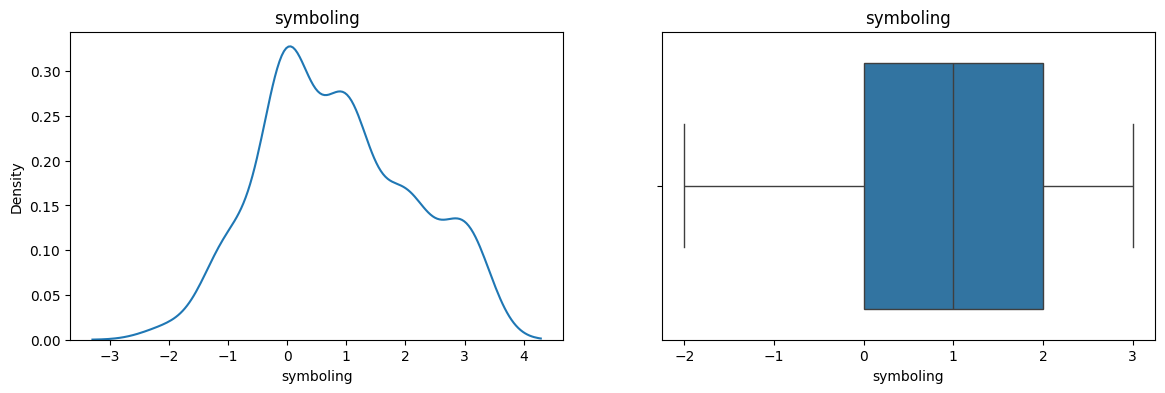

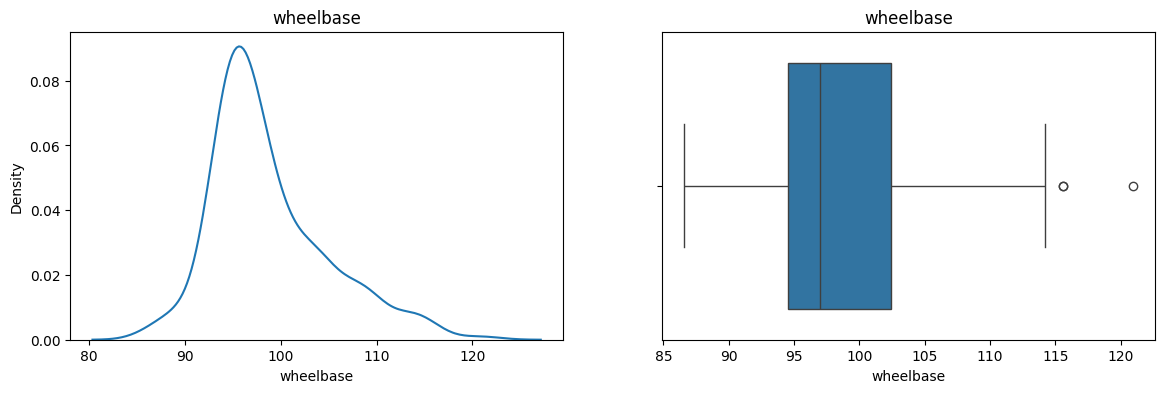

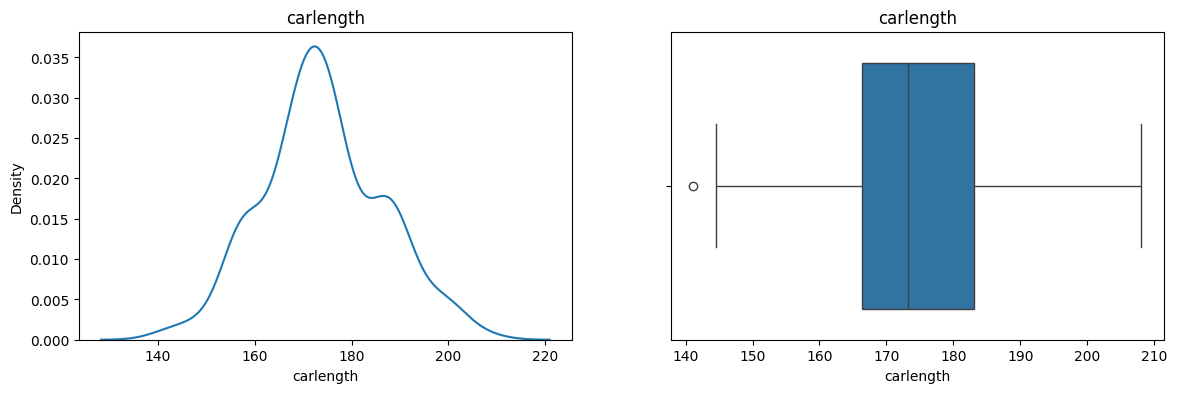

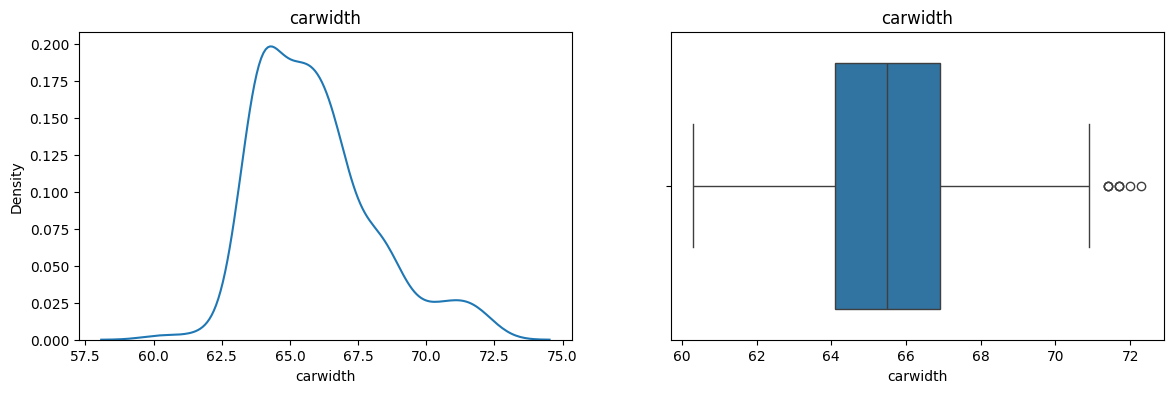

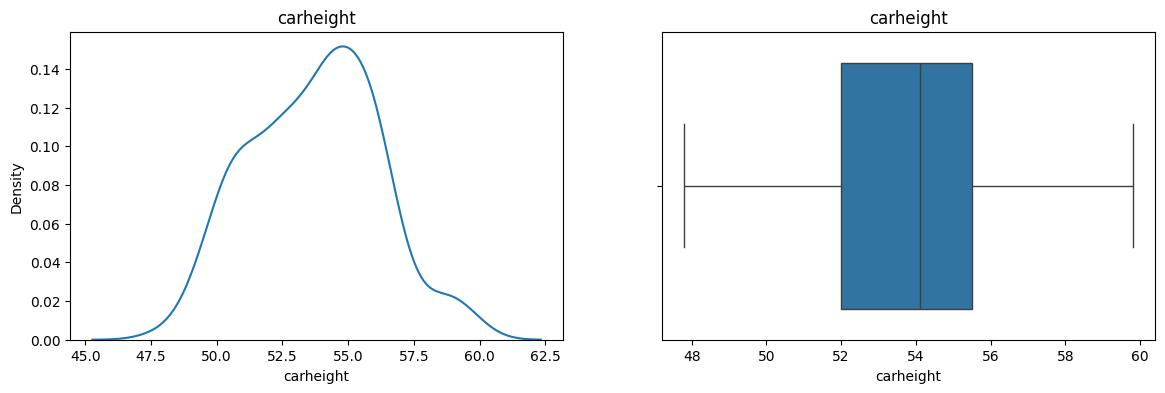

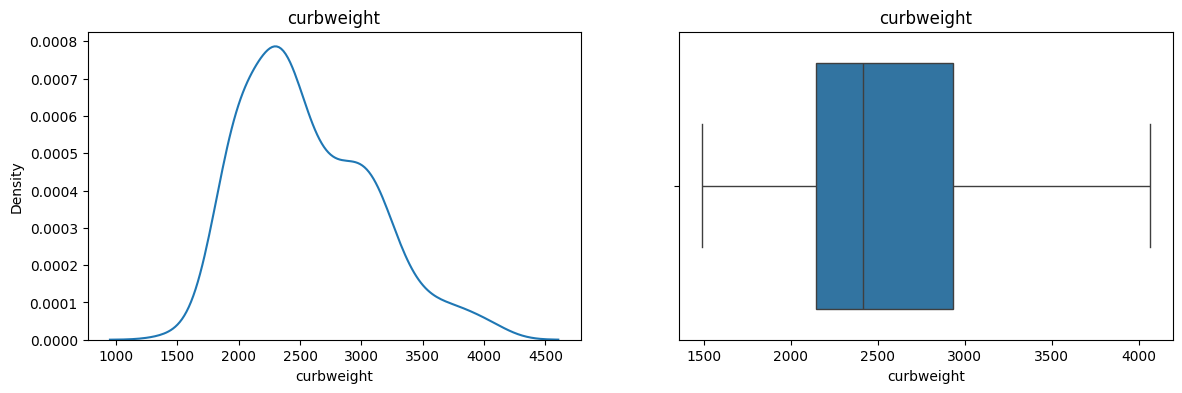

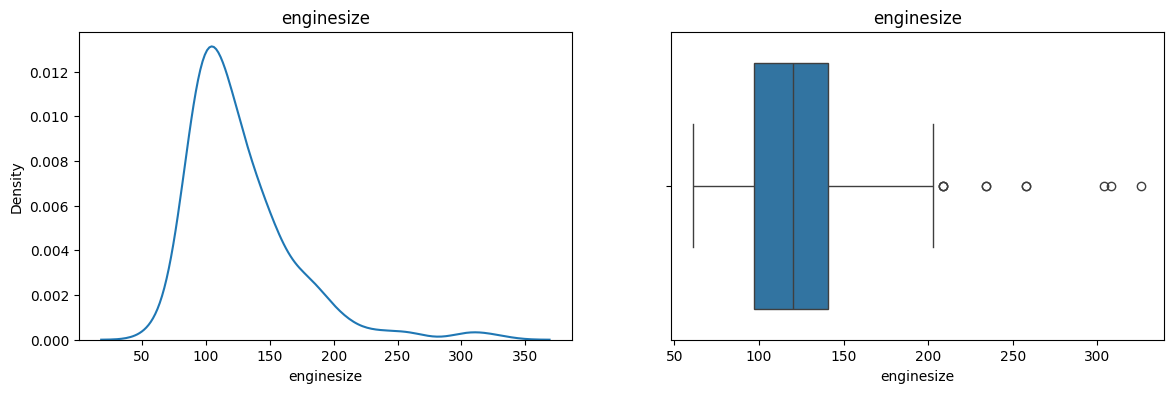

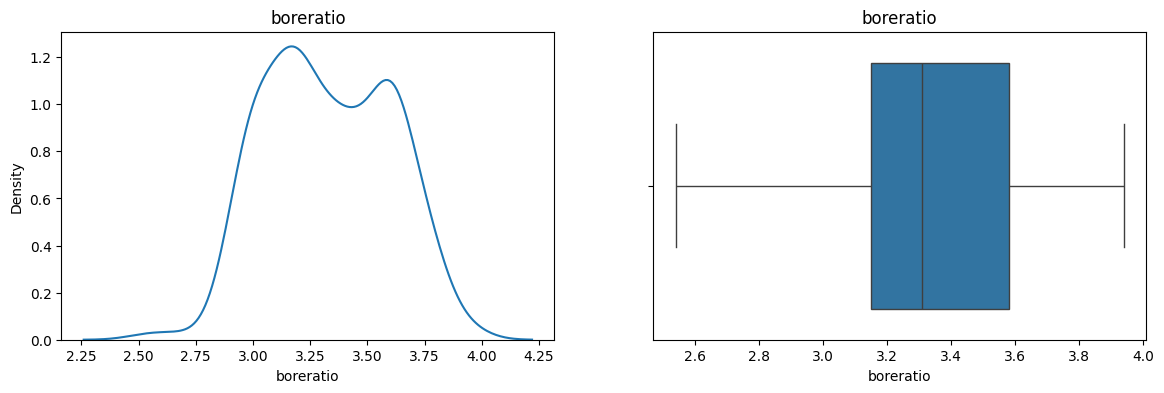

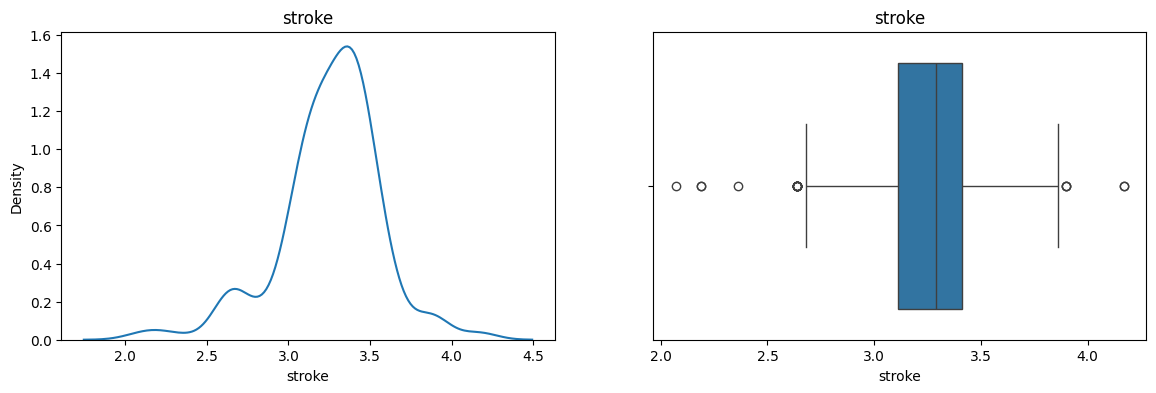

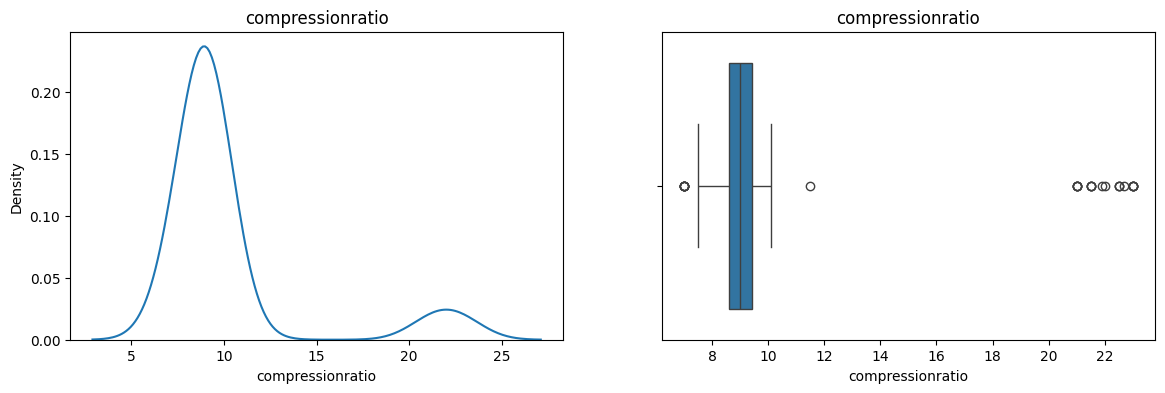

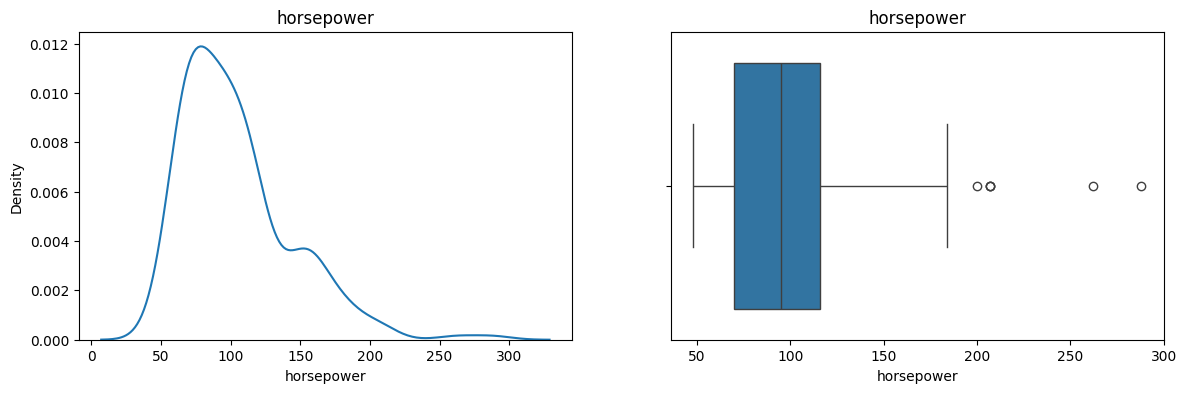

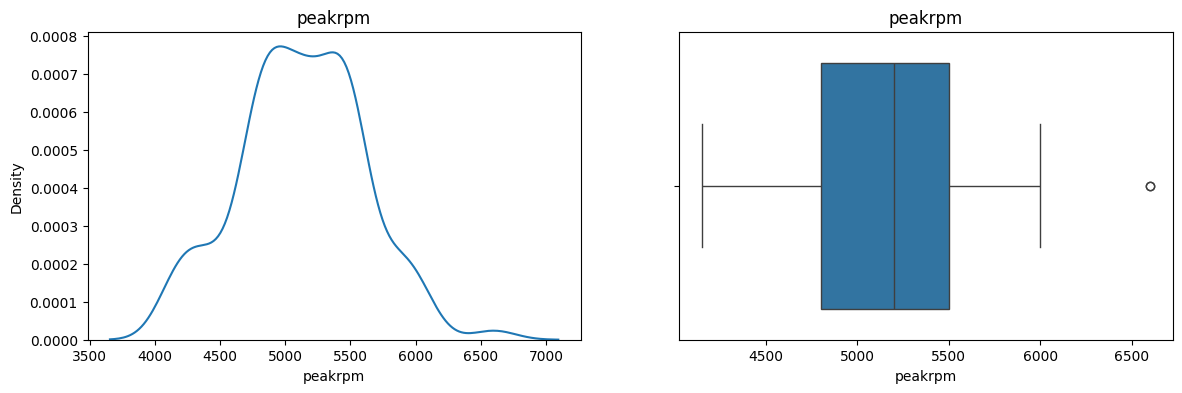

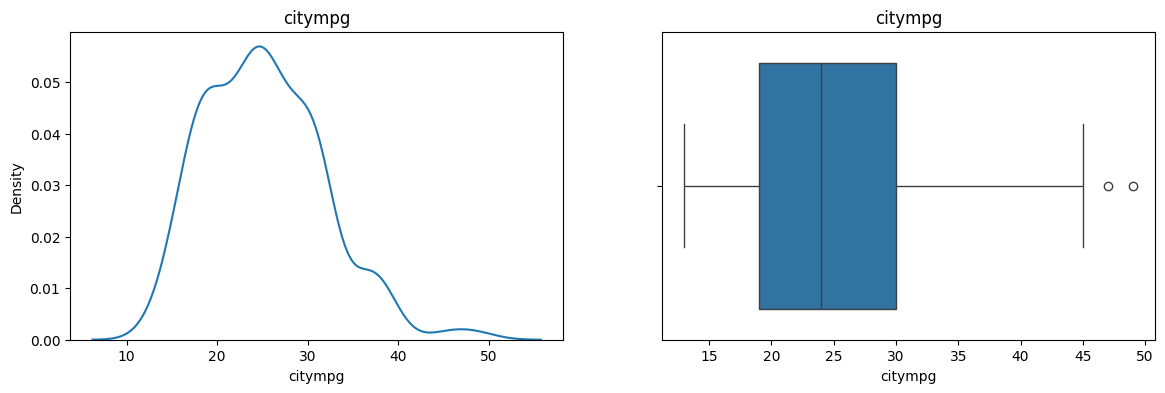

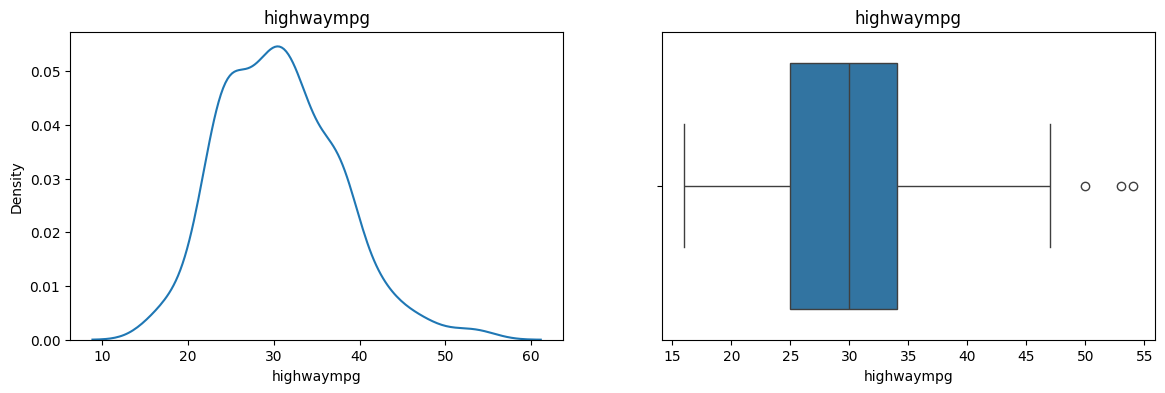

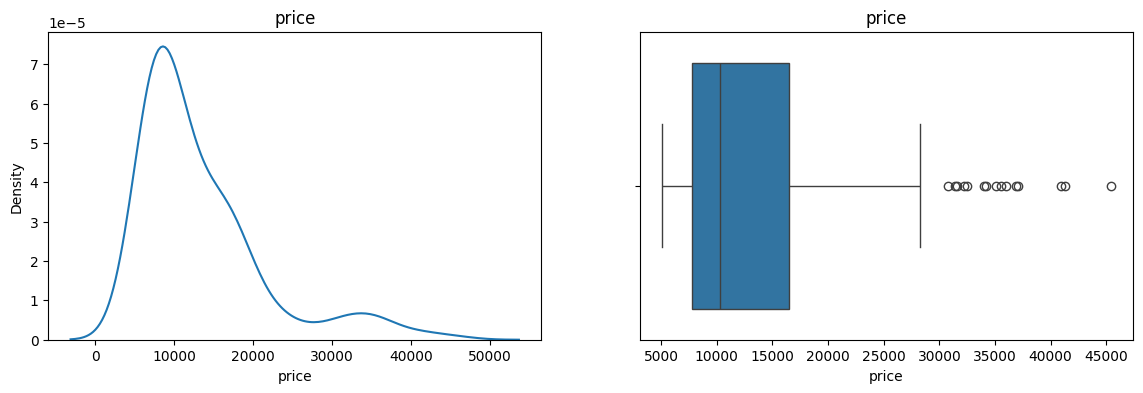

In [8]:
# see the data distributions of numeric columns
for col in data.columns:
    if data[col].dtype == 'object':
        continue

    plt.figure(figsize=(14,4))
    plt.subplot(121)
    sns.kdeplot(data=data, x = col)
    plt.title(col)

    plt.subplot(122)
    sns.boxplot(data=data, x = col, orient= 'h')
    plt.title(col)

    plt.show()

In [9]:
# see value counts of the string columns
for col in data.columns:

    if data[col].dtype != 'object':
        continue

    print(f"{data[col].value_counts()} \n\n")

fueltypes
gas       185
diesel     20
Name: count, dtype: int64 


aspiration
std      168
turbo     37
Name: count, dtype: int64 


doornumbers
four    115
two      90
Name: count, dtype: int64 


carbody
sedan          96
hatchback      70
wagon          25
hardtop         8
convertible     6
Name: count, dtype: int64 


drivewheels
fwd    120
rwd     76
4wd      9
Name: count, dtype: int64 


enginelocation
front    202
rear       3
Name: count, dtype: int64 


enginetype
ohc      148
ohcf      15
ohcv      13
dohc      12
l         12
rotor      4
dohcv      1
Name: count, dtype: int64 


cylindernumber
four      159
six        24
five       11
eight       5
two         4
twelve      1
three       1
Name: count, dtype: int64 


fuelsystem
mpfi    94
2bbl    66
idi     20
1bbl    11
spdi     9
4bbl     3
mfi      1
spfi     1
Name: count, dtype: int64 




In [10]:
# make doornumbers -> numeric
data['doornumbers']= data['doornumbers'].apply(lambda x: '4' if x == 'four' else '2')

In [11]:
data['doornumbers'].value_counts()

,count
doornumbers,
4,115
2,90


In [12]:
data['doornumbers']= data['doornumbers'].astype(int)

In [13]:
# make the 'carbody' col. to have := 2 modes + 'others'
top_car_bodies= data['carbody'].value_counts().nlargest(2)

data['carbody']= data['carbody'].apply(lambda x: x if x in top_car_bodies else 'Others')

In [14]:
# features and labels
X= data.drop('price', axis=1)
Y= data['price']

In [15]:
# train test split
X_train, X_test, y_train, y_test= train_test_split(X, Y, test_size=0.2)

In [16]:
# get the numeric and string features
numeric_features = X_train.select_dtypes(exclude=['object']).columns
categorical_features = X_train.select_dtypes(include=['object']).columns

In [17]:
# seperate the numeric features -> categorical and continious
for col in numeric_features:
    print(f"{col} := {len(data[col].value_counts())}\n")

symboling := 6

doornumbers := 2

wheelbase := 53

carlength := 75

carwidth := 44

carheight := 49

curbweight := 171

enginesize := 44

boreratio := 38

stroke := 37

compressionratio := 32

horsepower := 59

peakrpm := 23

citympg := 29

highwaympg := 30



In [18]:
# Set a threshold for unique values (e.g., columns with fewer than 10 unique values are likely categorical)
unique_value_threshold = 10

# Identify continuous numeric columns
continuous_numeric_cols = [col for col in numeric_features if data[col].nunique() >= unique_value_threshold]

In [19]:
# string transformer := Simple imputer + One Hot Encoder

string_transformer= Pipeline([
    ('string_imputer', SimpleImputer(strategy='most_frequent')),
    ('one_hot_encoder', OneHotEncoder(sparse_output=False, drop='first', handle_unknown='ignore'))
])

In [20]:
# Building a preprocessor using ColumnTransformer to handle different types of preprocessing
# The preprocessor combines:
# 1) KNN Imputer for both categorical and continuous numeric columns
# 2) Power Transformer for continuous numeric columns only
# 3) String transformer for categorical/string columns

preprocessor = ColumnTransformer([
    # Apply KNNImputer to fill missing values in numeric columns (both categorical and continuous numeric features)
    ('knn_imputer', KNNImputer(weights='distance'), numeric_features),

    # Apply PowerTransformer to normalize continuous numeric columns to make data more Gaussian-like
    ('power_transformer', PowerTransformer(), continuous_numeric_cols),

    # Apply the String transformer to handle categorical string features
    ('string_transformer', string_transformer, categorical_features)
])

In [21]:
# model
model= xgb.XGBRegressor()

In [22]:
# pipeline
pipe= Pipeline([
    ('preprocessor', preprocessor),
    ('model', model)
])

In [23]:
# fit
pipe.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('knn_imputer',
                                                  KNNImputer(weights='distance'),
                                                  Index(['symboling', 'doornumbers', 'wheelbase', 'carlength', 'carwidth',
       'carheight', 'curbweight', 'enginesize', 'boreratio', 'stroke',
       'compressionratio', 'horsepower', 'peakrpm', 'citympg', 'highwaympg'],
      dtype='object')),
                                                 ('power_transformer',
                                                  PowerTran...
                              feature_types=None, gamma=None, grow_policy=None,
                              importance_type=None,
                              interaction_constraints=None, learning_rate=None,
                              max_bin=None, max_cat_threshold=None,
                              max_cat_to_onehot=None, max_delta_step=None,
                              max_depth=None, max_leaves=None,
                              min_child_weight=None, missing=nan,
                              monotone_constraints=None, multi_strategy=None,
                              n_estimators=None, n_jobs=None,
                              num_parallel_tree=None, random_state=None, ...))])

In [24]:
# predict
y_preds= pipe.predict(X_test)

/usr/local/lib/python3.11/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [7] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


In [25]:
mean_absolute_error(y_test, y_preds)

1933.9608662347562

In [26]:
mean_squared_error(y_test, y_preds)

7241904.079416194

In [27]:
np.sqrt(mean_squared_error(y_test, y_preds))

np.float64(2691.078608925461)

In [28]:
r2_score(y_test, y_preds)

0.9029070113871425

In [29]:
# find the best model

best_r2= 0
best_model= -1

models= [LinearRegression(), RandomForestRegressor(), xgb.XGBRegressor(), GradientBoostingRegressor(),AdaBoostRegressor(), BayesianRidge()]

for model in models:

    pipe= Pipeline([
        ('preprocessor', preprocessor),
        ('model', model)
    ])

    pipe.fit(X_train, y_train)

    y_preds= pipe.predict(X_test)

    r2_sc= r2_score(y_test, y_preds)

    if r2_sc > best_r2:
        best_r2= r2_sc
        best_model= model

    print(f"{model} := {r2_sc}\n")

print(f"\nBest model := {best_model} with an R2 -> {best_r2}")

/usr/local/lib/python3.11/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [7] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


LinearRegression() := 0.8296709355399805



/usr/local/lib/python3.11/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [7] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [7] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


RandomForestRegressor() := 0.9119869231230743

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             gamma=None, grow_policy=None, importance_type=None,
             interaction_constraints=None, learning_rate=None, max_bin=None,
             max_cat_threshold=None, max_cat_to_onehot=None,
             max_delta_step=None, max_depth=None, max_leaves=None,
             min_child_weight=None, missing=nan, monotone_constraints=None,
             multi_strategy=None, n_estimators=None, n_jobs=None,
             num_parallel_tree=None, random_state=None, ...) := 0.9029070113871425



/usr/local/lib/python3.11/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [7] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [7] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


GradientBoostingRegressor() := 0.909851645472959

AdaBoostRegressor() := 0.901808150119624

BayesianRidge() := 0.8414015730041958


Best model := RandomForestRegressor() with an R2 -> 0.9119869231230743


/usr/local/lib/python3.11/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [7] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


In [30]:
# find the best params for PCA
max_r2= 0
best_comps= 0

for i in range(1, 24):

    pipe= Pipeline([
        ('preprocessor', preprocessor),
        ('PCA', PCA(n_components=i)),
        ('model', model)
    ])

    pipe.fit(X_train, y_train)

    y_preds= pipe.predict(X_test)

    r2_sc= r2_score(y_test, y_preds)

    if r2_sc > max_r2:
        max_r2= r2_sc
        best_comps= i

    print(f"{i} comps := {r2_sc}")

print(f"\n\nBest comps: {best_comps}, R2: {max_r2}")

/usr/local/lib/python3.11/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [7] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [7] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [7] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


1 comps := 0.33272771362051656
2 comps := 0.6383769937709393
3 comps := 0.8147476663632294


/usr/local/lib/python3.11/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [7] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [7] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [7] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


4 comps := 0.8362296457023455
5 comps := 0.8316532860889072
6 comps := 0.8351526283091356


/usr/local/lib/python3.11/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [7] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [7] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [7] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


...

/usr/local/lib/python3.11/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [7] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [7] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [7] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


16 comps := 0.8404825706526055
17 comps := 0.840463922632548
18 comps := 0.8408552944581615


/usr/local/lib/python3.11/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [7] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [7] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [7] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


19 comps := 0.8408883809624448
20 comps := 0.8411120388081486
21 comps := 0.8411117269644792
22 comps := 0.841215350883912
23 comps := 0.8413281384743188


Best comps: 23, R2: 0.8413281384743188


/usr/local/lib/python3.11/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [7] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [7] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
